# 📌 Telco Customer Churn Prediction – Supervised Learning Capstone

1. Business Problem
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Training & Comparison
7. Cross-Validation
8. Model Interpretation
9. Risk Segmentation
10. Business Recommendations
11. Conclusion & Future Work

### 🔥 Project Highlights
- Compared 6 supervised learning models
- Applied 5-fold cross-validation
- Achieved ROC-AUC of 0.8458
- Interpreted coefficients using odds ratios
- Built risk segmentation strategy

# Import Libraries & Read Data

In [1]:
import numpy as np          
import pandas as pd                      
import matplotlib.pyplot as plt        
import seaborn as sns

In [5]:
df=pd.read_csv('Telco-Customer-Churn.csv')

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Check

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


# Data Cleaning

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Exploratory Data Analysis (EDA)

<Axes: xlabel='Churn', ylabel='count'>

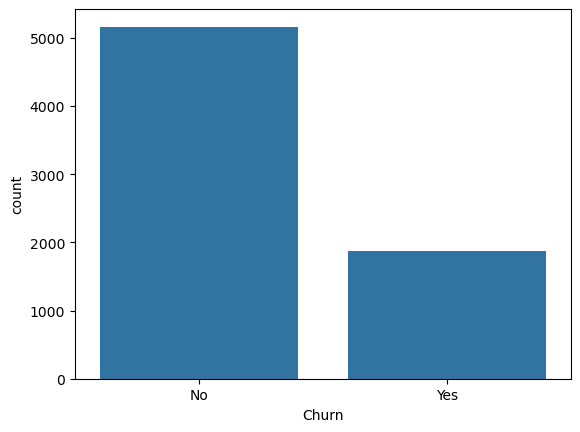

In [10]:
sns.countplot(data=df,x='Churn')

Text(0.5, 1.0, 'Tenure vs Churn')

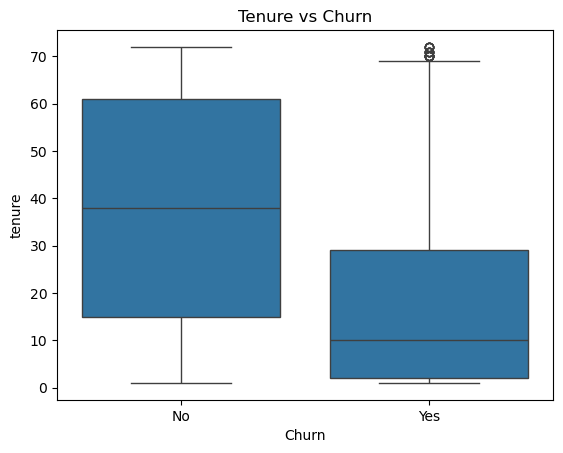

In [11]:
## Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")

Text(0.5, 1.0, 'Monthly Charges vs Churn')

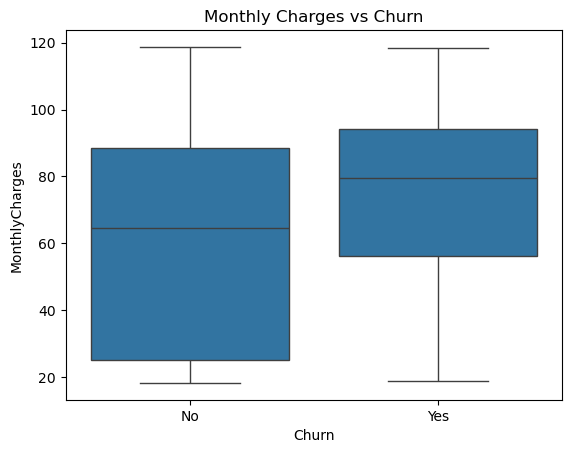

In [12]:
## Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")

In [13]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


## From EDA 
### 1. Tenure Insight
##### Low tenure → high churn
##### New customers leave more

### 2. Monthly Charges Insight
##### Higher monthly charges → more churn tendency

### 3. Contract Insight
##### Month-to-month → highest churn
##### Two-year → lowest churn

# Feature Engineering

In [14]:
def tenure_group(x):
    if x <= 12:
        return '0-12 Months'
    elif x <= 24:
        return '12-24 Months'
    elif x <= 48:
        return '24-48 Months'
    else:
        return 'Over 48 Months'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

In [15]:
tenure_churn=pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100
tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 Months,52.321839,47.678161
12-24 Months,71.289062,28.710938
24-48 Months,79.611041,20.388959
Over 48 Months,90.486824,9.513176


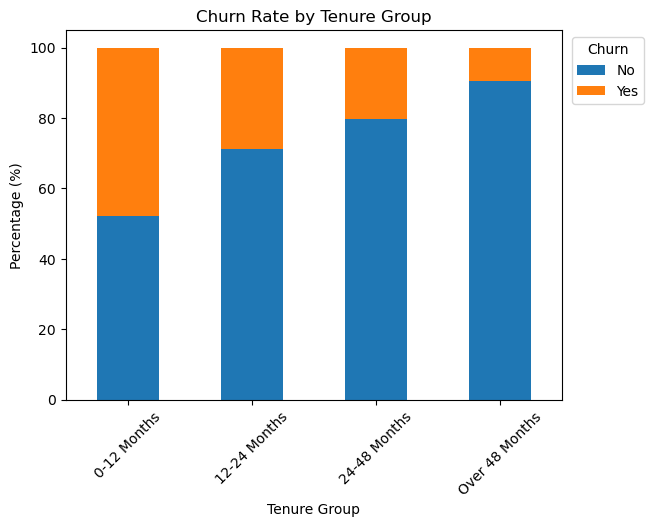

In [16]:
tenure_churn.plot(kind='bar', stacked=True)
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(title="Churn",loc=(1.02,0.8))

# Preparing Data for Modeling

In [17]:
df = df.drop('customerID', axis=1)

In [18]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

In [19]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [20]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_12-24 Months,TenureGroup_24-48 Months,TenureGroup_Over 48 Months
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,0,True,True,True,True,False,...,True,True,False,True,False,False,True,True,False,False
7028,0,72,103.20,7362.90,0,False,True,True,True,False,...,True,True,False,True,True,False,False,False,False,True
7029,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,True,False,True,False,False,False,False
7030,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False


In [21]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup'],
      dtype='object')

# Define Features (X) and Target (y)

In [22]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Train-Test Split (With Stratification)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Train Decision Tree

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# Make Predictions

In [25]:
y_pred = dt.predict(X_test)

# Evaluate

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1216  333]
 [ 284  277]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1549
           1       0.45      0.49      0.47       561

    accuracy                           0.71      2110
   macro avg       0.63      0.64      0.64      2110
weighted avg       0.72      0.71      0.71      2110



# Train Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [28]:
y_pred_rf = rf.predict(X_test)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[1388  161]
 [ 296  265]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.62      0.47      0.54       561

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.70      2110
weighted avg       0.77      0.78      0.77      2110



In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [31]:
best_rf = grid.best_estimator_
best_rf

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [32]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob)

np.float64(0.8163659148734909)

In [33]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.163936
2,MonthlyCharges,0.146961
1,tenure,0.143179
25,Contract_Two year,0.051797
10,InternetService_Fiber optic,0.045544
28,PaymentMethod_Electronic check,0.035716
32,TenureGroup_Over 48 Months,0.029102
24,Contract_One year,0.026610
4,gender_Male,0.026577
26,PaperlessBilling_Yes,0.024796


In [34]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')*100

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [35]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')*100

Churn,0,1
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


# Gradient Boosting

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [37]:
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.64      0.50      0.56       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.71      2110
weighted avg       0.78      0.79      0.78      2110

ROC-AUC: 0.8386101550192235


In [38]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.324285
10,InternetService_Fiber optic,0.190411
28,PaymentMethod_Electronic check,0.091393
25,Contract_Two year,0.066670
3,TotalCharges,0.064001
2,MonthlyCharges,0.063931
24,Contract_One year,0.039854
16,DeviceProtection_No internet service,0.026636
13,OnlineSecurity_Yes,0.022744
26,PaperlessBilling_Yes,0.016615


# Logistic Regression, SVM, KNN

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": best_rf,   # tuned RF
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Recall (Churn)": report["1"]["recall"],
        "Precision (Churn)": report["1"]["precision"],
        "F1 (Churn)": report["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)
comparison_df.sort_values(by="ROC-AUC", ascending=False)

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

,Model,Accuracy,Recall (Churn),Precision (Churn),F1 (Churn),ROC-AUC
5,Gradient Boosting,0.792891,0.504456,0.640271,0.564307,0.838610
0,Logistic Regression,0.793839,0.524064,0.636364,0.574780,0.837026
4,Random Forest,0.765877,0.721925,0.545087,0.621166,0.834942
2,SVM,0.734123,0.000000,0.000000,0.000000,0.781823
1,KNN,0.757820,0.449198,0.555066,0.496552,0.735918
3,Decision Tree,0.707583,0.493761,0.454098,0.473100,0.639928


# Cross-Validation

In [40]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    print(name, "Mean ROC-AUC:", scores.mean())

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

Logistic Regression Mean ROC-AUC: 0.8458491455019738
KNN Mean ROC-AUC: 0.7435725567042304
SVM Mean ROC-AUC: 0.7916428965588213
Decision Tree Mean ROC-AUC: 0.6539171412785437
Random Forest Mean ROC-AUC: 0.8435436388379735
Gradient Boosting Mean ROC-AUC: 0.8454392069696564


# 📊 Final Model Comparison (ROC-AUC)

To visually compare model performance, we plot the cross-validated ROC-AUC scores of the top performing models.  
This helps identify which model generalizes best across different data splits.

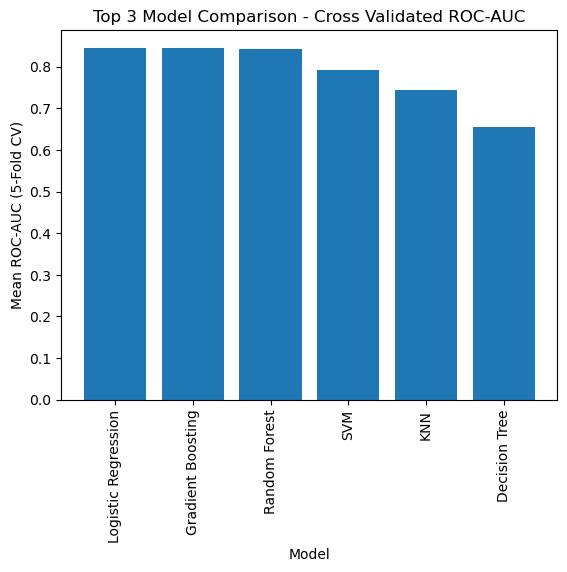

In [41]:
models_names = ["Logistic Regression", "Gradient Boosting", "Random Forest","SVM", "KNN","Decision Tree"]
roc_scores = [0.8458, 0.8454, 0.8435,0.7916,0.7435,0.6539]

plt.figure()
plt.bar(models_names, roc_scores)

plt.xlabel("Model")
plt.ylabel("Mean ROC-AUC (5-Fold CV)")
plt.title("Top 3 Model Comparison - Cross Validated ROC-AUC")
plt.xticks(rotation=90)

plt.show()

# Selecting the Best Model
Based on the model comparison results, Logistic Regression achieved the highest ROC-AUC score and demonstrated stable performance across cross-validation. Therefore, Logistic Regression is selected as the final model for further evaluation and interpretation.

# ROC Curve Analysis
The ROC (Receiver Operating Characteristic) curve visualizes the performance of the classification model by plotting the True Positive Rate against the False Positive Rate at different classification thresholds.
A curve closer to the top-left corner indicates better model performance.

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


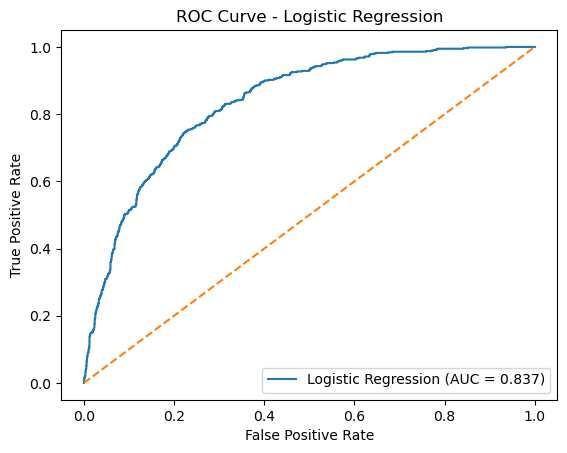

In [42]:
# Final model selection
final_model = LogisticRegression(max_iter=1000)

# Train the model
final_model.fit(X_train, y_train)

from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class
y_prob = final_model.predict_proba(X_test)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.show()

# Extract Coefficients

In [43]:
log_model = models["Logistic Regression"]

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coeff_df = coeff_df.sort_values(by="Coefficient", ascending=False)

In [44]:
coeff_df["Odds_Ratio"] = coeff_df["Coefficient"].apply(lambda x: np.exp(x))
coeff_df.head(10)

,Feature,Coefficient,Odds_Ratio
10,InternetService_Fiber optic,0.680459,1.974783
32,TenureGroup_Over 48 Months,0.356711,1.428624
9,MultipleLines_Yes,0.353922,1.424644
28,PaymentMethod_Electronic check,0.342950,1.409098
26,PaperlessBilling_Yes,0.333333,1.395613
21,StreamingTV_Yes,0.220701,1.246950
8,MultipleLines_No phone service,0.213217,1.237653
23,StreamingMovies_Yes,0.196371,1.216978
0,SeniorCitizen,0.187455,1.206176
29,PaymentMethod_Mailed check,0.084555,1.088233


In [45]:
coeff_df.tail(10)

,Feature,Coefficient,Odds_Ratio
11,InternetService_No,-0.115021,0.891347
15,OnlineBackup_Yes,-0.204576,0.814993
31,TenureGroup_24-48 Months,-0.228871,0.795431
6,Dependents_Yes,-0.251870,0.777346
19,TechSupport_Yes,-0.430650,0.650087
30,TenureGroup_12-24 Months,-0.437023,0.645957
7,PhoneService_Yes,-0.439645,0.644265
13,OnlineSecurity_Yes,-0.444004,0.641463
24,Contract_One year,-0.721818,0.485868
25,Contract_Two year,-1.419478,0.241840


In [46]:
scores = cross_val_score(log_model, X, y, cv=5, scoring='roc_auc')
print("Mean:", scores.mean())
print("Std Dev:", scores.std())

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

Mean: 0.8458491455019738
Std Dev: 0.010697540340650288


D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Understanding Why Customers Churn

## 📊 Customer Churn Drivers – Visual Dashboard Summary
This section presents a visual summary of the key factors contributing to customer churn.  
The objective is to clearly demonstrate churn patterns for non-technical stakeholders.

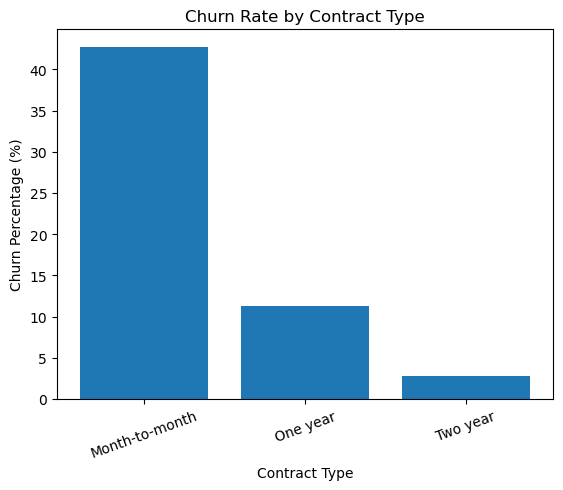

In [47]:
# Churn Rate by Contract Type
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

plt.figure()
plt.bar(contract_churn.index, contract_churn[1])

plt.xlabel("Contract Type")
plt.ylabel("Churn Percentage (%)")
plt.title("Churn Rate by Contract Type")

plt.xticks(rotation=20)
plt.show()

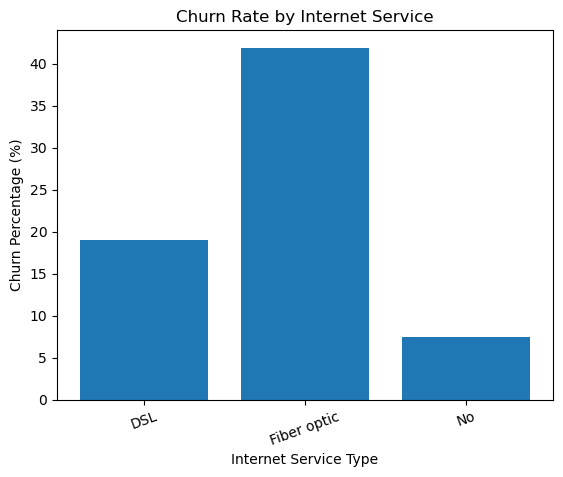

In [48]:
# Churn Rate by Internet Service 
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

plt.figure()
plt.bar(internet_churn.index, internet_churn[1])

plt.xlabel("Internet Service Type")
plt.ylabel("Churn Percentage (%)")
plt.title("Churn Rate by Internet Service")

plt.xticks(rotation=20)
plt.show()

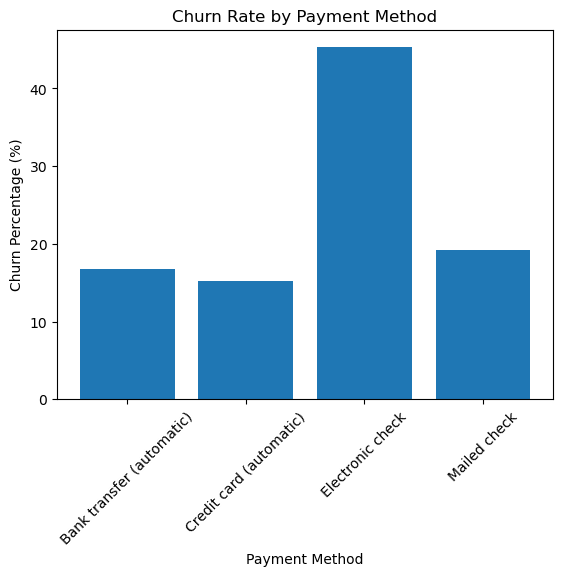

In [49]:
# Churn Rate by Payment Method
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

plt.figure()
plt.bar(payment_churn.index, payment_churn[1])

plt.xlabel("Payment Method")
plt.ylabel("Churn Percentage (%)")
plt.title("Churn Rate by Payment Method")

plt.xticks(rotation=45)
plt.show()

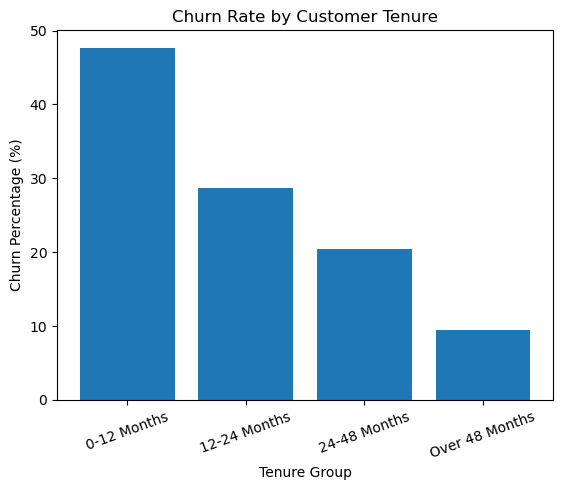

In [50]:
# Churn Rate by Tenure Group
tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100

plt.figure()
plt.bar(tenure_churn.index, tenure_churn[1])

plt.xlabel("Tenure Group")
plt.ylabel("Churn Percentage (%)")
plt.title("Churn Rate by Customer Tenure")

plt.xticks(rotation=20)
plt.show()

### 📌 Key Observations

- Month-to-month customers show the highest churn rates.
- Fiber optic service users churn significantly more than DSL users.
- Electronic check payment method is associated with higher churn.
- Early lifecycle customers (0–12 months) are most vulnerable.

These insights align with the model interpretation and risk segmentation analysis.

# Risk Segmentation
### “Which customers are high risk and should be targeted first?”

In [51]:
# Get churn probabilities
log_model = models["Logistic Regression"]

probs = log_model.predict_proba(X_test)[:,1]

risk_df = pd.DataFrame({
    "Actual_Churn": y_test,
    "Predicted_Probability": probs
})

risk_df.head()

,Actual_Churn,Predicted_Probability
4214,0,0.192746
1815,0,0.350824
2370,0,0.048700
5453,0,0.050624
1786,0,0.033146


In [52]:
risk_df["Risk_Level"] = pd.cut(
    risk_df["Predicted_Probability"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_df["Risk_Level"].value_counts()

Risk_Level
Low Risk       1287
Medium Risk     517
High Risk       306
Name: count, dtype: int64

In [53]:
pd.crosstab(risk_df["Risk_Level"], risk_df["Actual_Churn"], normalize='index') * 100

Actual_Churn,0,1
Risk_Level,,
Low Risk,89.821290,10.178710
Medium Risk,57.640232,42.359768
High Risk,31.045752,68.954248


In [54]:
risk_df.sort_values(by="Predicted_Probability", ascending=False).head(20)

,Actual_Churn,Predicted_Probability,Risk_Level
3374,1,0.887629,High Risk
6359,1,0.879070,High Risk
3154,0,0.876842,High Risk
2626,1,0.867873,High Risk
2792,1,0.859638,High Risk
3721,1,0.855137,High Risk
4509,1,0.852856,High Risk
4577,1,0.852827,High Risk
6223,1,0.850434,High Risk
3340,0,0.847853,High Risk


# 📌 Executive Summary

After evaluating six supervised learning models, Logistic Regression achieved the highest cross-validated ROC-AUC (0.8458 ± 0.0107), demonstrating strong and stable performance.

Key churn drivers include:
- Fiber optic service
- Electronic check payment method
- Month-to-month contracts

Protective factors:
- Two-year contracts
- Tech support
- Online security

Risk segmentation identified 14% of customers as high-risk, among whom 69% actually churned, enabling targeted retention strategies.